In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import xgboost as xgb
import sys

# Sklearn Utilities
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.utils.class_weight import compute_sample_weight

CAFPYANA_DIR = "/exp/sbnd/app/users/nrowe/solo_caf/cafpyana/"

sys.path.append(CAFPYANA_DIR + 'pyanalib')
plt.style.use("/home/nrowe/mcs/dune.mplstyle")
import split_df_helpers as sh

In [123]:
dfs = sh.load_dfs(CAFPYANA_DIR + "mcs.df", ['slc','trk'])
slcdf = dfs['slc']
trkdf = dfs['trk']

clean_trkdf = trkdf[(trkdf.true_pdg == -211) | (trkdf.true_pdg == 211) | (trkdf.true_pdg == 2212) | (trkdf.true_pdg == 13)][selected_cols]

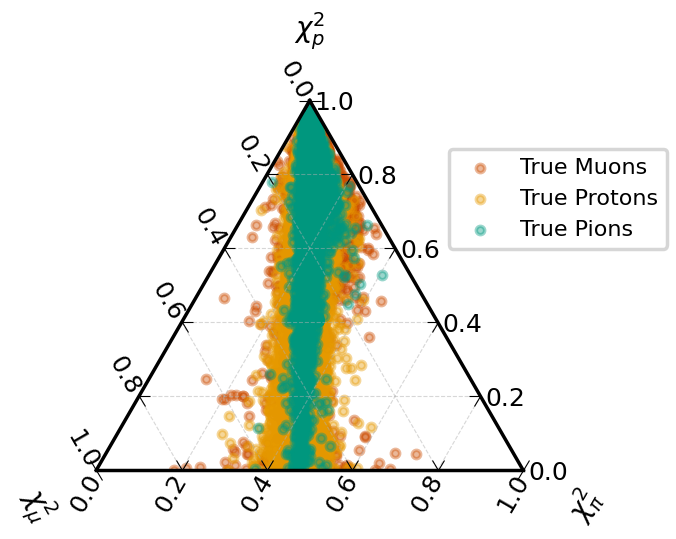

In [124]:
import matplotlib.pyplot as plt
import numpy as np
import mpltern

# 1. Apply maximum threshold cuts to clean raw outliers
cut_df = clean_trkdf[
    (clean_trkdf.chi2p <= 500)
    & (clean_trkdf.chi2u <= 100)
    & (clean_trkdf.chi2pi <= 100)
].copy()

# 4. Filter by true particle types
clean_trkdf_true_mu = cut_df[cut_df.true_pdg == 13]
clean_trkdf_true_p = cut_df[cut_df.true_pdg == 2212]
clean_trkdf_true_pi = cut_df[
    (cut_df.true_pdg == 211) | (cut_df.true_pdg == -211)
]

ax = plt.subplot(projection="ternary")

# 5. Plot equal-weight scaled variables within the cut limits
ax.scatter(
    clean_trkdf_true_mu.chi2p,
    clean_trkdf_true_mu.chi2u,
    clean_trkdf_true_mu.chi2pi,
    alpha=0.4,
    label="True Muons",
)
ax.scatter(
    clean_trkdf_true_p.chi2p,
    clean_trkdf_true_p.chi2u,
    clean_trkdf_true_p.chi2pi,
    alpha=0.4,
    label="True Protons",
)
ax.scatter(
    clean_trkdf_true_pi.chi2p,
    clean_trkdf_true_pi.chi2u,
    clean_trkdf_true_pi.chi2pi,
    alpha=0.4,
    label="True Pions",
)

ax.legend(bbox_to_anchor=(0.8, 0.9), loc="upper left")
ax.set_tlabel(r"$\chi^2_p$")
ax.set_llabel(r"$\chi^2_\mu$")
ax.set_rlabel(r"$\chi^2_\pi$")
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()

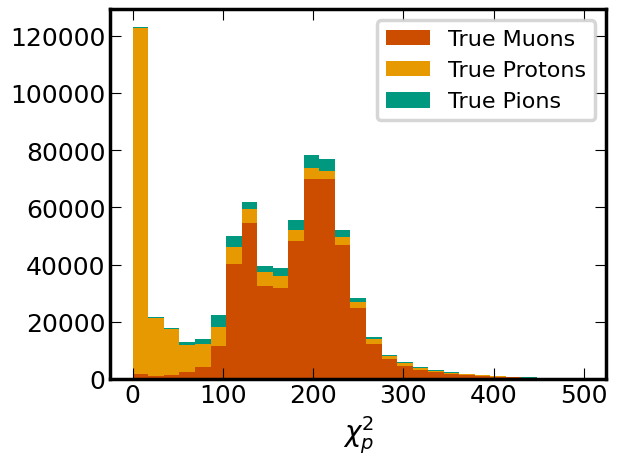

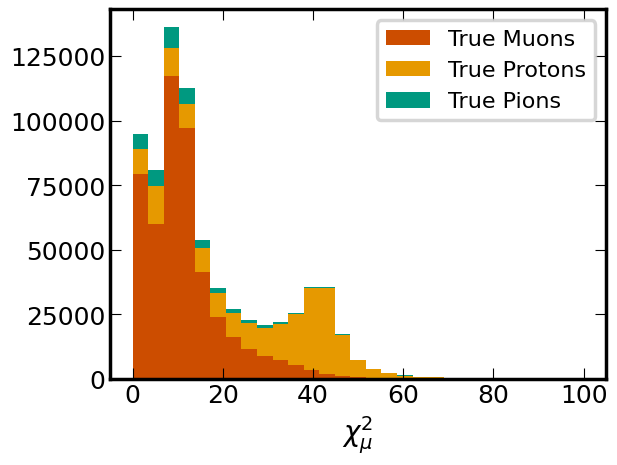

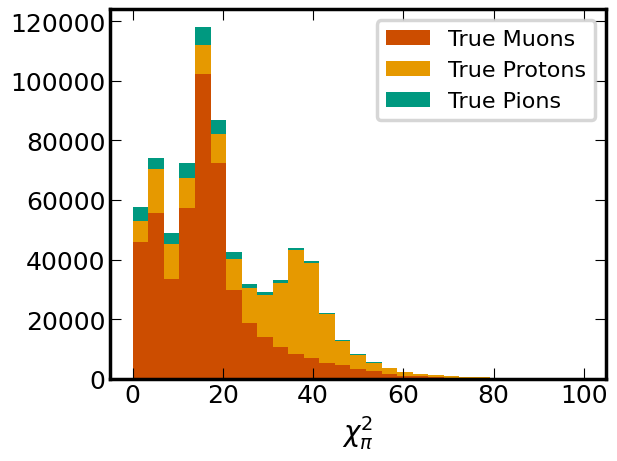

In [125]:
b = np.linspace(0, 500.0, 30)
_ = plt.hist([clean_trkdf_true_mu.chi2p, clean_trkdf_true_p.chi2p, clean_trkdf_true_pi.chi2p], label=["True Muons", "True Protons", "True Pions"], stacked=True, bins=b)
plt.xlabel(r"$\chi^2_{p}$")
plt.legend()
plt.show()

b = np.linspace(0, 100.0, 30)
_ = plt.hist([clean_trkdf_true_mu.chi2u, clean_trkdf_true_p.chi2u, clean_trkdf_true_pi.chi2u], label=["True Muons", "True Protons", "True Pions"], stacked=True, bins=b)
plt.xlabel(r"$\chi^2_{\mu}$")
plt.legend()
plt.show()

b = np.linspace(0, 100.0, 30)
_ = plt.hist([clean_trkdf_true_mu.chi2pi, clean_trkdf_true_p.chi2pi, clean_trkdf_true_pi.chi2pi], label=["True Muons", "True Protons", "True Pions"], stacked=True, bins=b)
plt.xlabel(r"$\chi^2_{\pi}$")
plt.legend()
plt.show()

/exp/sbnd/app/users/nrowe/solo_caf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


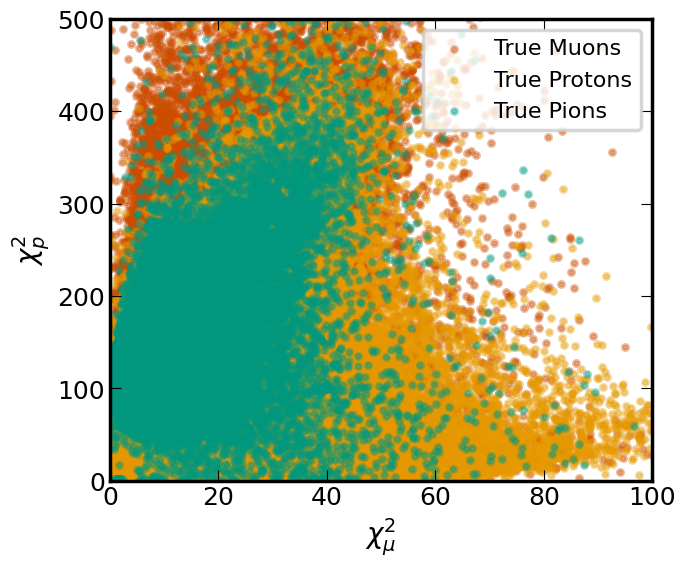

In [126]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

for pdg, label, color in [
    (13, "True Muons", "C0"),
    (2212, "True Protons", "C1"),
    (211, "True Pions", "C2"),
]:
    df = clean_trkdf[np.abs(clean_trkdf.true_pdg) == pdg]
    ax.scatter(
        df.chi2u,
        df.chi2p,
        alpha=0.4,
        label=label,
        s=15,
    )
ax.set_xlim(0, 100)
ax.set_ylim(0, 500)
ax.set_xlabel(r"$\chi^2_\mu$")
ax.set_ylabel(r"$\chi^2_p$")
ax.legend()
plt.show()

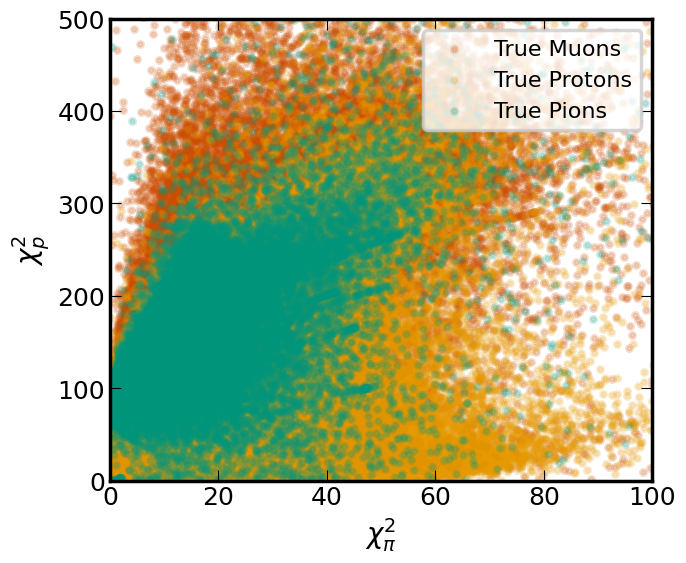

In [127]:
fig, ax = plt.subplots(figsize=(7, 6))

for pdg, label, color in [
    (13, "True Muons", "C0"),
    (2212, "True Protons", "C1"),
    (211, "True Pions", "C2"),
]:
    df = clean_trkdf[np.abs(clean_trkdf.true_pdg) == pdg]
    ax.scatter(
        df.chi2pi,
        df.chi2p,
        alpha=0.2,
        label=label,
        s=15,
    )
ax.set_xlim(0, 100)
ax.set_ylim(0, 500)
ax.set_xlabel(r"$\chi^2_\pi$")
ax.set_ylabel(r"$\chi^2_p$")
ax.legend()
plt.show()

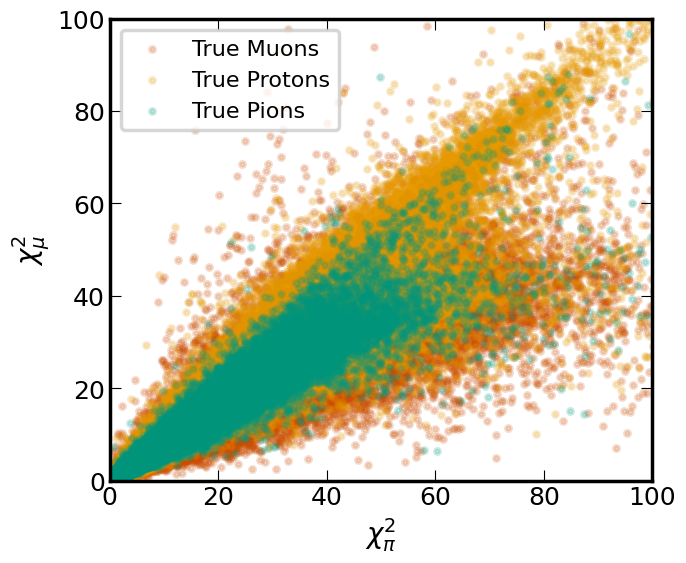

In [128]:
fig, ax = plt.subplots(figsize=(7, 6))

for pdg, label, color in [
    (13, "True Muons", "C0"),
    (2212, "True Protons", "C1"),
    (211, "True Pions", "C2"),
]:
    df = clean_trkdf[np.abs(clean_trkdf.true_pdg) == pdg]
    ax.scatter(
        df.chi2pi,
        df.chi2u,
        alpha=0.2,
        label=label,
        s=15,
    )
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel(r"$\chi^2_\pi$")
ax.set_ylabel(r"$\chi^2_\mu$")
ax.legend()
plt.show()

In [139]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb


def train_and_evaluate_bdt(
    df,
    training_cols,
    truth_col="true_pdg",
    target_pdgs=(-211, 13),
    num_boost_round=2000,
    test_size=0.5,
    random_state=123,
    title_suffix="",
):
    # 1. Dataset selection and filtering
    selected_cols = list(set(training_cols + [truth_col]))
    clean_df = df[df[truth_col].isin(target_pdgs)][selected_cols].copy()

    le = LabelEncoder()
    clean_df["target"] = le.fit_transform(clean_df[truth_col])

    X = clean_df[training_cols]
    y = clean_df["target"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # 2. Construct QuantileDMatrix objects
    sample_weights = compute_sample_weight("balanced", y_train)
    dtrain = xgb.QuantileDMatrix(
        X_train, label=y_train, weight=sample_weights
    )
    dtest = xgb.QuantileDMatrix(X_test, label=y_test, ref=dtrain)

    # 3. Configure XGBoost parameters
    params = {
        "device": "cuda",
        "tree_method": "hist",
        "objective": "multi:softprob",
        "num_class": len(target_pdgs),
        "eval_metric": "mlogloss",
    }

    # 4. Train Model
    evals_result = {}
    booster = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=[(dtrain, "train"), (dtest, "test")],
        evals_result=evals_result,
        verbose_eval=False,
    )

    # 5. Plotting Evaluation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # --- Panel 1: Learning Curve ---
    rounds = range(len(evals_result["train"]["mlogloss"]))
    ax1.plot(
        rounds,
        evals_result["train"]["mlogloss"],
        label="Train (Weighted)",
        linewidth=2,
    )
    ax1.plot(
        rounds,
        evals_result["test"]["mlogloss"],
        label="Test (Unweighted)",
        linewidth=2,
    )
    ax1.set_xlabel("Boosting Round")
    ax1.set_ylabel("Log Loss")
    ax1.set_title(
        f"XGBoost Learning Curve{' - ' + title_suffix if title_suffix else ''}"
    , fontsize=12)
    ax1.grid(True, linestyle="--", alpha=0.4)
    ax1.legend(loc="upper right")

    # --- Panel 2: BDT Score Separation ---
    preds = booster.predict(dtest)
    pdg_map = dict(zip(range(len(le.classes_)), le.classes_))
    test_pdg = y_test.map(pdg_map)

    pdg_labels = {13: r"True $\mu^-$", -211: r"True $\pi^-$", 2212: r"True $p$"}
    bins = np.linspace(0, 1, 40)

    for pdg_val in np.unique(test_pdg):
        mask = test_pdg == pdg_val
        scores = preds[mask, 1] if preds.ndim > 1 else preds[mask]
        label_str = pdg_labels.get(pdg_val, f"PDG {pdg_val}")

        ax2.hist(
            scores,
            bins=bins,
            histtype="step",
            linewidth=2,
            density=True,
            label=label_str,
        )

    ax2.set_xlabel("BDT Classifier Score")
    ax2.set_ylabel("Probability Density")
    ax2.set_title(
        f"BDT Separation{' - ' + title_suffix if title_suffix else ''}"
    , fontsize=12)
    ax2.set_xlim(0, 1)
    ax2.set_yscale('log')
    ax2.grid(True, linestyle="--", alpha=0.4)
    ax2.legend(bbox_to_anchor=(1.04, 1.0), loc="upper left")

    plt.tight_layout()
    plt.show()

    return booster, evals_result

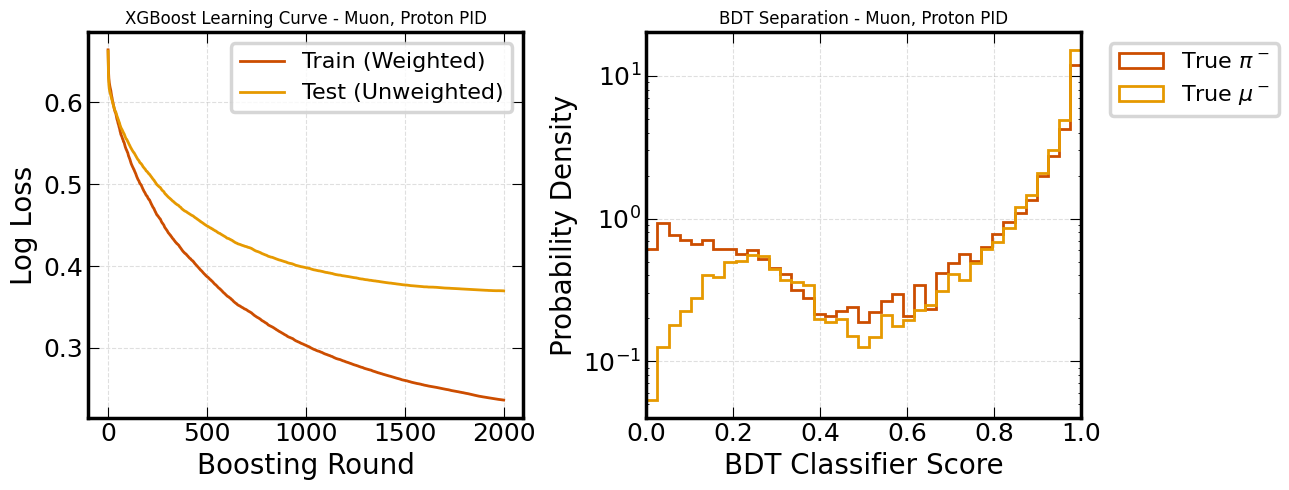

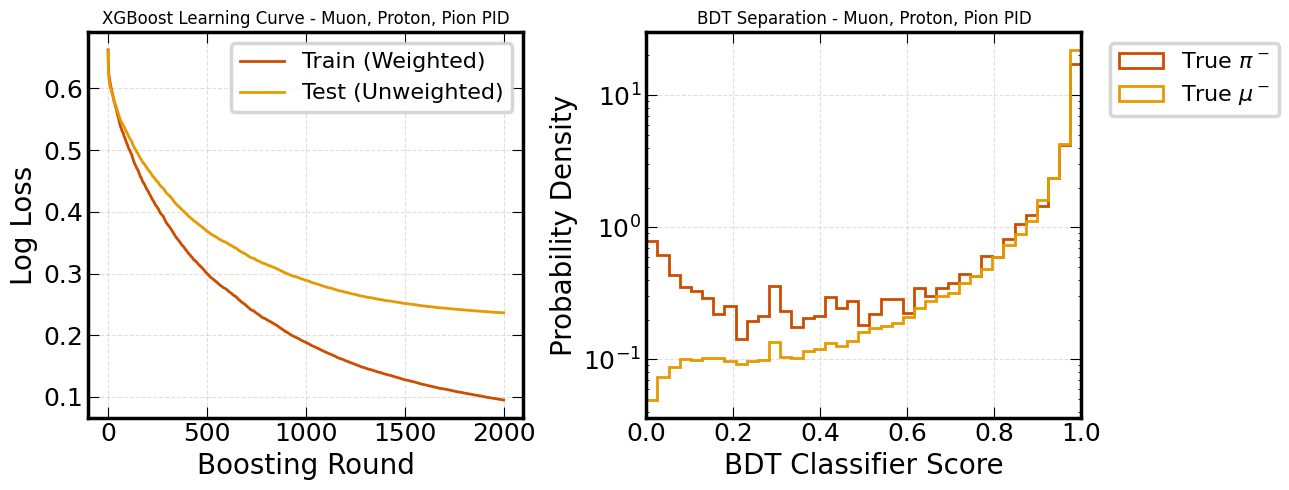

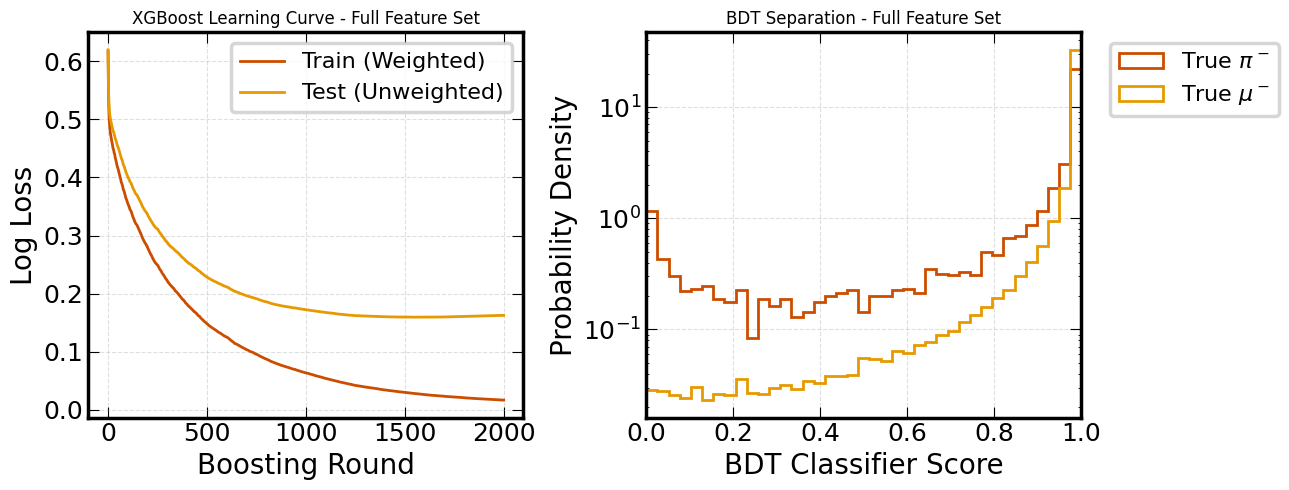

In [140]:
cols_simple_pid = [
    "chi2u",
    "chi2p",
]

cols_full_pid = [
    "chi2u",
    "chi2p",
    "chi2pi",
]

cols_full = [
    "chi2u",
    "chi2p",
    "chi2pi",
    "maxlen",
    "maxang",
    "minlen",
    "minang",
    "avglen",
    "avgang",
    "stdlen",
    "stdang",
]

cleaner_trkdf = clean_trkdf[
    (clean_trkdf.chi2u <= 150) & 
    (clean_trkdf.chi2p <= 500) &
    (clean_trkdf.chi2pi <= 150) &
    (clean_trkdf.minang != -999)
]

model_full, hist_full = train_and_evaluate_bdt(
    cleaner_trkdf, cols_simple_pid, title_suffix="Muon, Proton PID"
)

model_full, hist_full = train_and_evaluate_bdt(
    cleaner_trkdf, cols_full_pid, title_suffix="Muon, Proton, Pion PID"
)

model_full, hist_full = train_and_evaluate_bdt(
    cleaner_trkdf, cols_full, title_suffix="Full Feature Set"
)

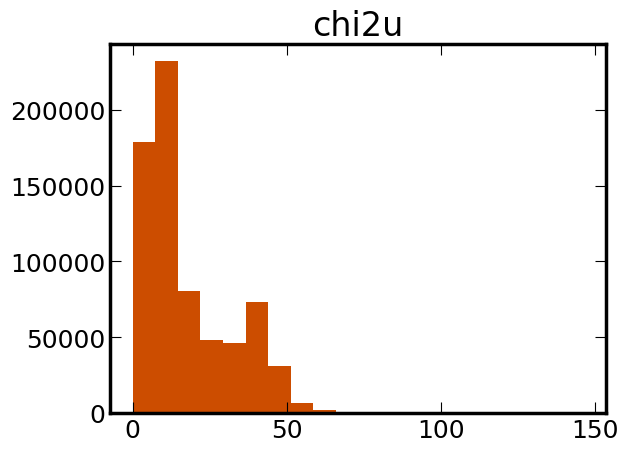

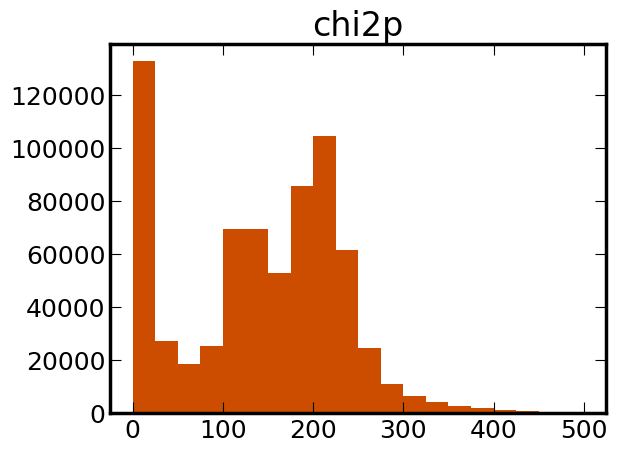

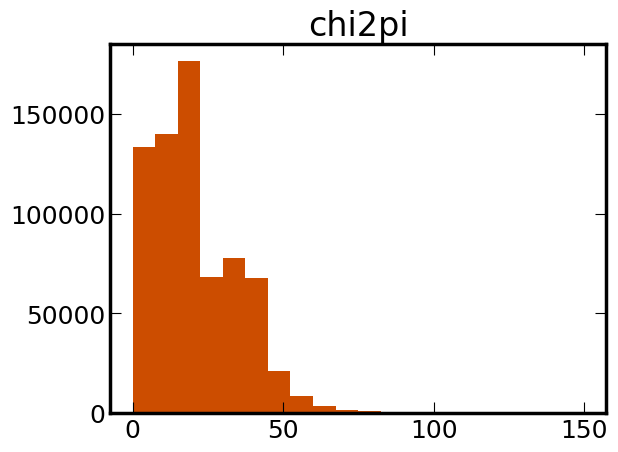

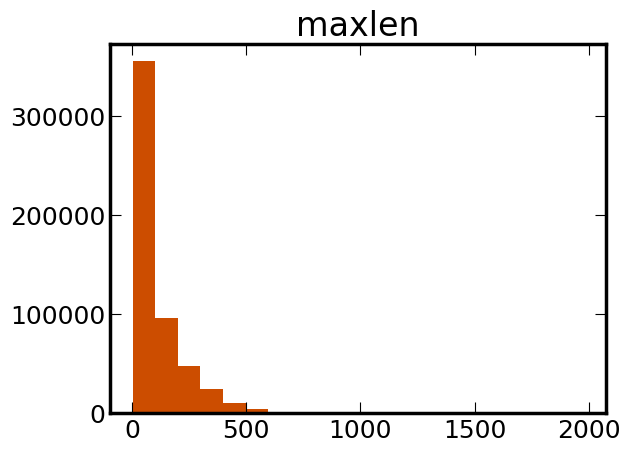

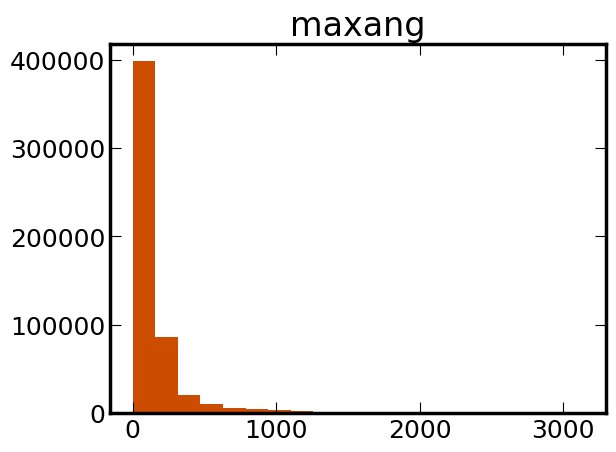

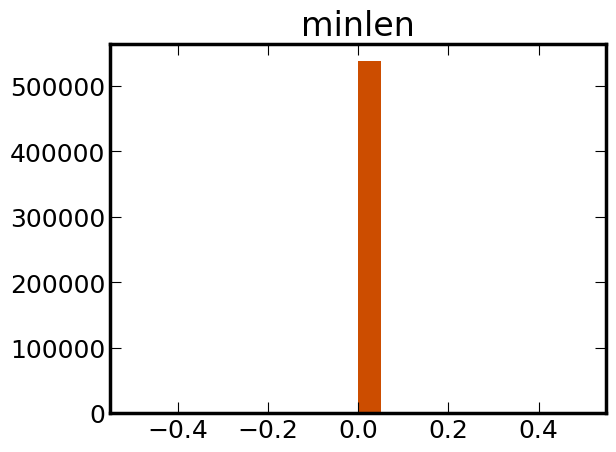

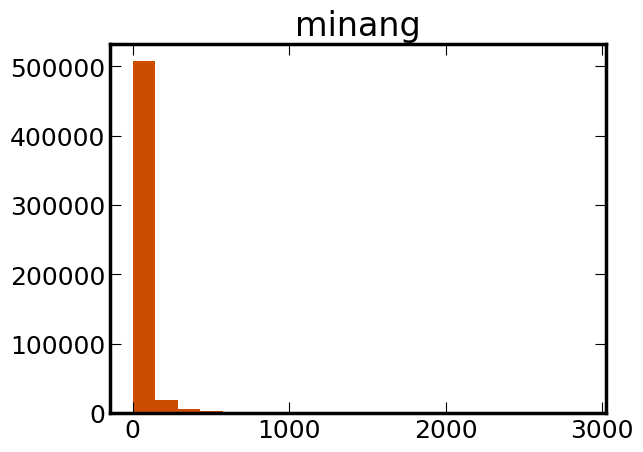

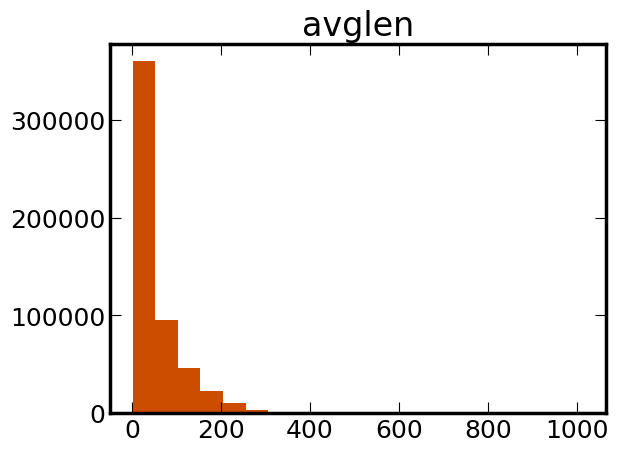

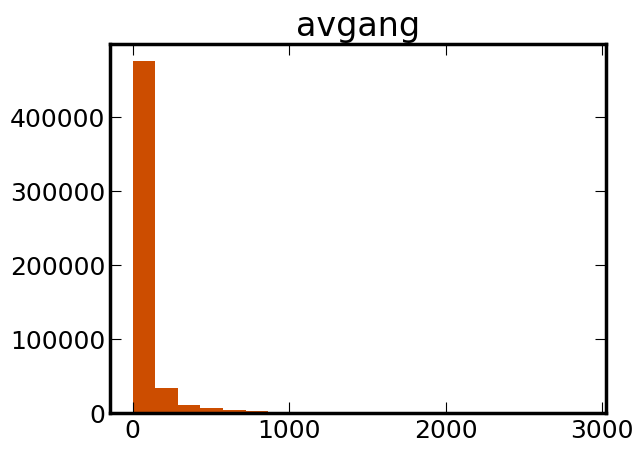

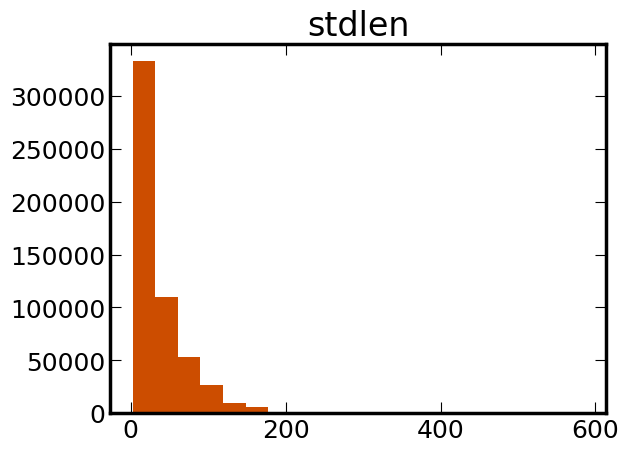

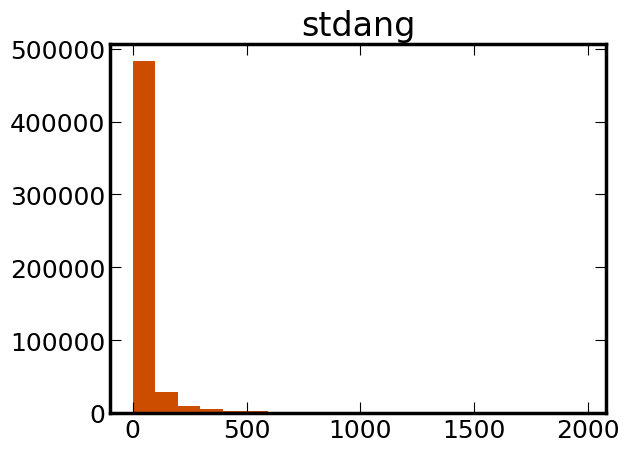

In [132]:
for c in cols_full:
    plt.title(c)
    plt.hist(cleaner_trkdf[c], bins=20)
    plt.show()